In [40]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from src.evaluation.metrics import (
    # compute_whole_body_suv_mae,
    # compute_brain_outlier_score,
    # compute_organ_bias,
    # compute_tac_bias,
    compute_whole_body_mu_mae,
)

In [41]:
filepath_gt_ct = "data/sub-000/ct-label/ct.nii.gz"
filepath_pred_ct = "src/cs_model/pseudo-ct.nii.gz"
filepath_pred_baseline = "src/baseline/pseudo-ct-baseline.nii.gz"

img1 = nib.load(filepath_gt_ct)
data1 = img1.get_fdata()

img2 = nib.load(filepath_pred_ct)
data2 = img2.get_fdata()

img3 = nib.load(filepath_pred_baseline)
data3 = img3.get_fdata()

In [42]:
print(f"given ct image shape: {img1.shape}")
print(f"given ct converted to data shape: {data1.shape}")

print(f"own pred ct image shape: {img2.shape}")
print(f"own pred ct converted to data shape: {data2.shape}")

print(f"baseline pred ct image shape: {img3.shape}")
print(f"baseline pred ct converted to data shape: {data3.shape}")

# print("ground truth")
# print('min:', data1.min())
# print('max:', data1.max())
# print('mean:', data1.mean())
# print('std:', data1.std())

given ct image shape: (512, 512, 531)
given ct converted to data shape: (512, 512, 531)
own pred ct image shape: (512, 512, 531)
own pred ct converted to data shape: (512, 512, 531)
baseline pred ct image shape: (512, 512, 531)
baseline pred ct converted to data shape: (512, 512, 531)


In [ ]:
slice_index = data1.shape[2] // 2

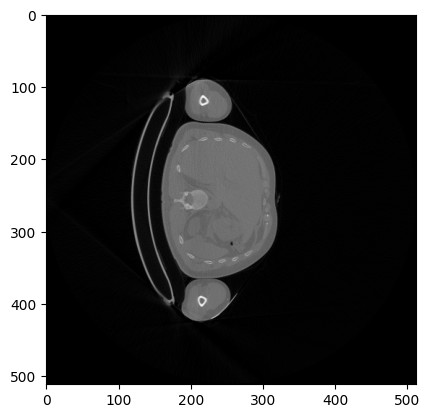

In [ ]:
plt.imshow(data1[:, :, slice_index], cmap="gray")
plt.show()

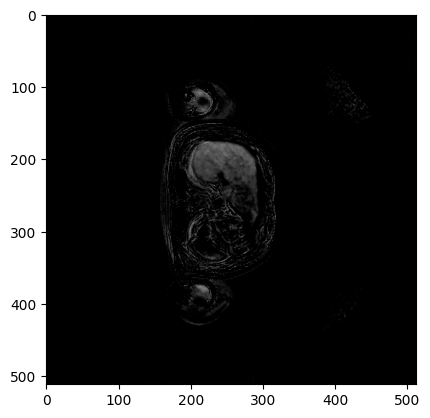

In [29]:
# plt.imshow(data2[:, :, slice_index], cmap="gray")
plt.imshow(data2[:,:,slice_index], cmap="gray", vmin=-1000, vmax=2000)
plt.show()

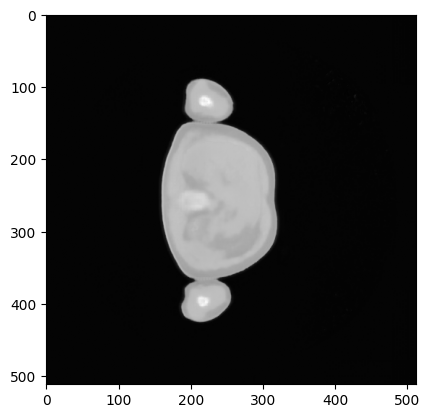

In [ ]:
plt.imshow(data3[:, :, slice_index], cmap="gray")
plt.show()

In [17]:
from src.evaluation.metrics import (
    # compute_whole_body_suv_mae,
    # compute_brain_outlier_score,
    # compute_organ_bias,
    # compute_tac_bias,
    compute_whole_body_mu_mae,
)

In [ ]:
compute_whole_body_mu_mae(
    filepath_pred_ct,
    filepath_gt_ct,
    "data/sub-000/ct-label/body_seg.nii.gz",
    "data/sub-000/ct-label/organ_seg.nii.gz",
    exclusion_cm=4.0,
    save_mask_path=None,
)

np.float64(0.08184736322637652)

In [ ]:
compute_whole_body_mu_mae(
    filepath_pred_baseline,
    filepath_gt_ct,
    "data/sub-000/ct-label/body_seg.nii.gz",
    "data/sub-000/ct-label/organ_seg.nii.gz",
    exclusion_cm=4.0,
    save_mask_path=None,
)

# np.float64(0.006004375143993909)

np.float64(0.006004375143993909)

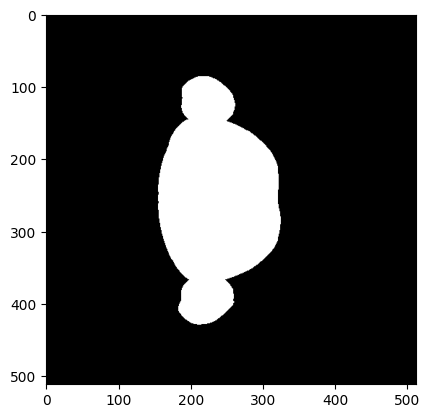

In [36]:
zero_pred_mask = "data/sub-000/ct-label/prediction_mask.nii.gz"
img_pred_mask = nib.load(zero_pred_mask)
data_pred_mask = img_pred_mask.get_fdata()

plt.imshow(data_pred_mask[:,:,slice_index], cmap="gray")
# plt.imshow(data3[:, :, slice_index], cmap="gray")

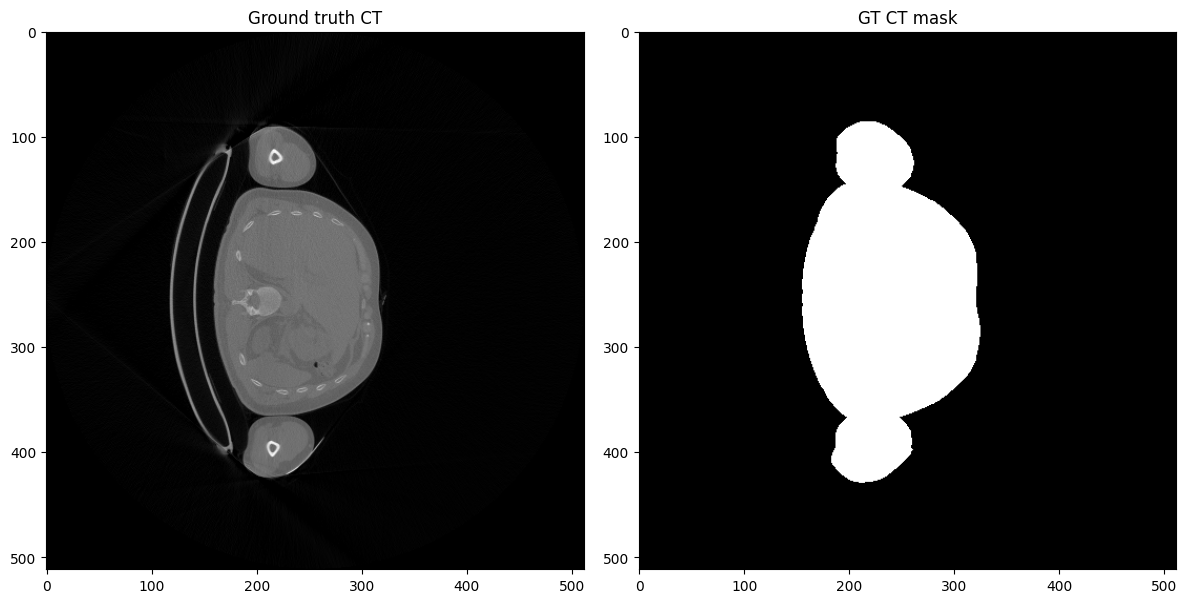

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(data1[:,:,slice_index], cmap="gray")
axes[0].set_title("Ground truth CT")
axes[1].imshow(data_pred_mask[:,:,slice_index], cmap="gray")
axes[1].set_title("GT CT mask")
plt.tight_layout()
plt.show()